In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/carrie1/ecommerce-data/data.csv


# Data Cleaning 

In [2]:
#loading the dataframe as data
data = pd.read_csv('/kaggle/input/datasets/carrie1/ecommerce-data/data.csv', encoding='ISO-8859-1')
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [3]:
#sorting the data by asc order for InvoiveDate col
data.sort_values(by = 'InvoiceDate')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
#making sure it is sorted 
#and taking a look at the end date to know the data timeframe
data.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [5]:
#take a look at the data info 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
data.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/2011 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


### data cleaning for RFM
* Recency: When that specific person last purchased.
* Frequency: How often that specific person buys.
* Monetary Value: How much that specific person has spent in total.

In [7]:
#droping the N/A rows of CustomerID because 
#RFM model need to be grouped by the 
data.dropna(subset = ['CustomerID'],inplace= True)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [9]:
# i noticed that i still have some empty cells 
# in the data set so i will count its no very quickly 
# Returns the total count of rows where EVERY column is NaN
data.isna().all(axis=1).sum()

np.int64(0)

# RFM df creation 

for recancy the date which we will train the model on well be the last date in the dataset +1 


In [10]:
# import datetime
import datetime as dt 

#changing the InvoiceDate to date datatype instead of object
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate']) 

#calculating the refernce date
reference_date = data['InvoiceDate'].max() + dt.timedelta(days=1)

#print it 
reference_date

Timestamp('2011-12-10 12:50:00')

In [11]:
#Printing the cols as a numpy array 
col_list = data.columns.to_numpy()
col_list

array(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'], dtype=object)

In [12]:
data['CustomerID'].unique()

array([17850., 13047., 12583., ..., 13298., 14569., 12713.])

In [13]:
#first customer all orders
data[data['CustomerID'] == 16446.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
194354,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446.0,United Kingdom
194355,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446.0,United Kingdom
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


In [15]:
# Creating a total price for each row as a first step of the aggrigation of the data 
data['TotalLinePrice'] = data['Quantity'] * data['UnitPrice']
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalLinePrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [16]:
# just making sure
data.loc[86900]

InvoiceNo                                   C543611
StockCode                                     71477
Description       COLOUR GLASS. STAR T-LIGHT HOLDER
Quantity                                         -2
InvoiceDate                     2011-02-10 14:38:00
UnitPrice                                      2.75
CustomerID                                  17850.0
Country                              United Kingdom
TotalLinePrice                                 -5.5
Name: 86900, dtype: object

In [17]:
# Creating the dataframe from which I will create the RFM 
# I will aggregate the invoices 
invoice_df = data.groupby('InvoiceNo', as_index = False ).agg(
    TotalPriceOfInvoice = ('TotalLinePrice' , 'sum'),
    CustomerID = ('CustomerID', 'first'),
    InvoiceDate = ('InvoiceDate' , 'max')
)
invoice_df

,InvoiceNo,TotalPriceOfInvoice,CustomerID,InvoiceDate
0,536365,139.12,17850.0,2010-12-01 08:26:00
1,536366,22.20,17850.0,2010-12-01 08:28:00
2,536367,278.73,13047.0,2010-12-01 08:34:00
3,536368,70.05,13047.0,2010-12-01 08:34:00
4,536369,17.85,13047.0,2010-12-01 08:35:00
...,...,...,...,...
22185,C581484,-168469.60,16446.0,2011-12-09 09:27:00
22186,C581490,-32.53,14397.0,2011-12-09 09:57:00
22187,C581499,-224.69,15498.0,2011-12-09 10:28:00
22188,C581568,-54.75,15311.0,2011-12-09 11:57:00


In [18]:
#
no_of_returns = invoice_df.loc[invoice_df['TotalPriceOfInvoice'] < 0, 'TotalPriceOfInvoice'].count()
no_of_returns

np.int64(3654)

In [19]:
all_transactions_nonaggrigate = invoice_df['TotalPriceOfInvoice'].count()
all_transactions_nonaggrigate

np.int64(22190)

In [20]:
(no_of_returns/all_transactions_nonaggrigate)*100

np.float64(16.466876971608833)

# RFM Return Handling Updates

## Feature Engineering ($R, F, M$ Refactor)

* **$M$ (Monetary):** Switched to **Net Monetary Value** ($\text{Gross} - \text{Returns}$). Allowed negative balances to reflect true net yield.
* **$F$ (Frequency):** Excluded 100%-returned transactions; return events no longer increment transaction count.
* **$R$ (Recency):** Tied strictly to purchase intent/fulfillment dates rather than refund processing timestamps.

In [21]:
#creating a col for purchase labeling
invoice_df['Is_Parchase'] = invoice_df['TotalPriceOfInvoice'] > 0
invoice_df

,InvoiceNo,TotalPriceOfInvoice,CustomerID,InvoiceDate,Is_Parchase
0,536365,139.12,17850.0,2010-12-01 08:26:00,True
1,536366,22.20,17850.0,2010-12-01 08:28:00,True
2,536367,278.73,13047.0,2010-12-01 08:34:00,True
3,536368,70.05,13047.0,2010-12-01 08:34:00,True
4,536369,17.85,13047.0,2010-12-01 08:35:00,True
...,...,...,...,...,...
22185,C581484,-168469.60,16446.0,2011-12-09 09:27:00,False
22186,C581490,-32.53,14397.0,2011-12-09 09:57:00,False
22187,C581499,-224.69,15498.0,2011-12-09 10:28:00,False
22188,C581568,-54.75,15311.0,2011-12-09 11:57:00,False


# WRONG Pass for testing


In [22]:
rfm = invoice_df.groupby('CustomerID').agg({
    # Recency: handles cases where a customer has 0 purchases (returns only)
    'InvoiceDate': lambda x: (reference_date - x[invoice_df.loc[x.index, 'Is_Parchase']].max()).days 
                             if not x[invoice_df.loc[x.index, 'Is_Parchase']].empty and pd.notna(x[invoice_df.loc[x.index, 'Is_Parchase']].max()) 
                             else None,
    
    # Frequency: counts unique purchase invoices
    'InvoiceNo': lambda x: x[invoice_df.loc[x.index, 'Is_Parchase']].nunique(),
    
    # Monetary: sums net spend (purchases minus returns)
    'TotalPriceOfInvoice': 'sum'
})

In [23]:
rfm

,InvoiceDate,InvoiceNo,TotalPriceOfInvoice
CustomerID,,,
12346.0,326.0,1,0.00
12347.0,2.0,7,4310.00
12348.0,75.0,4,1797.24
12349.0,19.0,1,1757.55
12350.0,310.0,1,334.40
...,...,...,...
18280.0,278.0,1,180.60
18281.0,181.0,1,80.82
18282.0,8.0,2,176.60


In [24]:
rfm.loc[rfm['TotalPriceOfInvoice'] == 0 ]

,InvoiceDate,InvoiceNo,TotalPriceOfInvoice
CustomerID,,,
12346.0,326.0,1,0.0
12558.0,8.0,1,0.0
12607.0,60.0,1,0.0
13256.0,NaN,0,0.0
13364.0,71.0,1,0.0
14557.0,85.0,1,0.0
14792.0,64.0,1,0.0
16742.0,47.0,1,0.0
16878.0,84.0,1,0.0


In [25]:
rfm.loc[rfm['TotalPriceOfInvoice'] < 0]

,InvoiceDate,InvoiceNo,TotalPriceOfInvoice
CustomerID,,,
12503.0,NaN,0,-1126.00
12505.0,NaN,0,-4.50
12605.0,NaN,0,-7.50
12666.0,NaN,0,-227.44
12870.0,NaN,0,-14.90
12943.0,NaN,0,-3.75
13154.0,NaN,0,-611.86
13672.0,301.0,2,-71.46
13693.0,NaN,0,-32.00


In [26]:
len(rfm)

4372

In [27]:
data['InvoiceDate'].isna().sum()
#this mean when i tried to keep the frequancy i got "retern only customers so i will clean them"

np.int64(0)

# correction of the RFM

In [28]:
#cleaning the rfm data 
# Fix existing rfm table in a new cell
rfm_clean = rfm.copy()

In [29]:
# Rename columns
rfm_clean.columns = ['Recency', 'Frequency', 'Monetary'] 

In [30]:
# Remove rows where Recency is NaN (return-only customers)
rfm_clean.dropna(subset=['Recency'], inplace=True)
# Keep only positive monetary spend and frequency > 0
rfm_clean = rfm_clean[(rfm_clean['Frequency'] > 0) & (rfm_clean['Monetary'] > 0)].copy()

In [31]:
rfm_clean.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,2.0,7,4310.00
12348.0,75.0,4,1797.24
12349.0,19.0,1,1757.55
12350.0,310.0,1,334.40
12352.0,36.0,8,1545.41


In [32]:
'''
here the difference between the len of rfm 
and the clean rfm on represent the data without 
the retern only customers
'''
len(rfm_clean)

4319

# RFM Data visualization

In [33]:
#import 
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Set visual style
sns.set_theme(style='whitegrid')

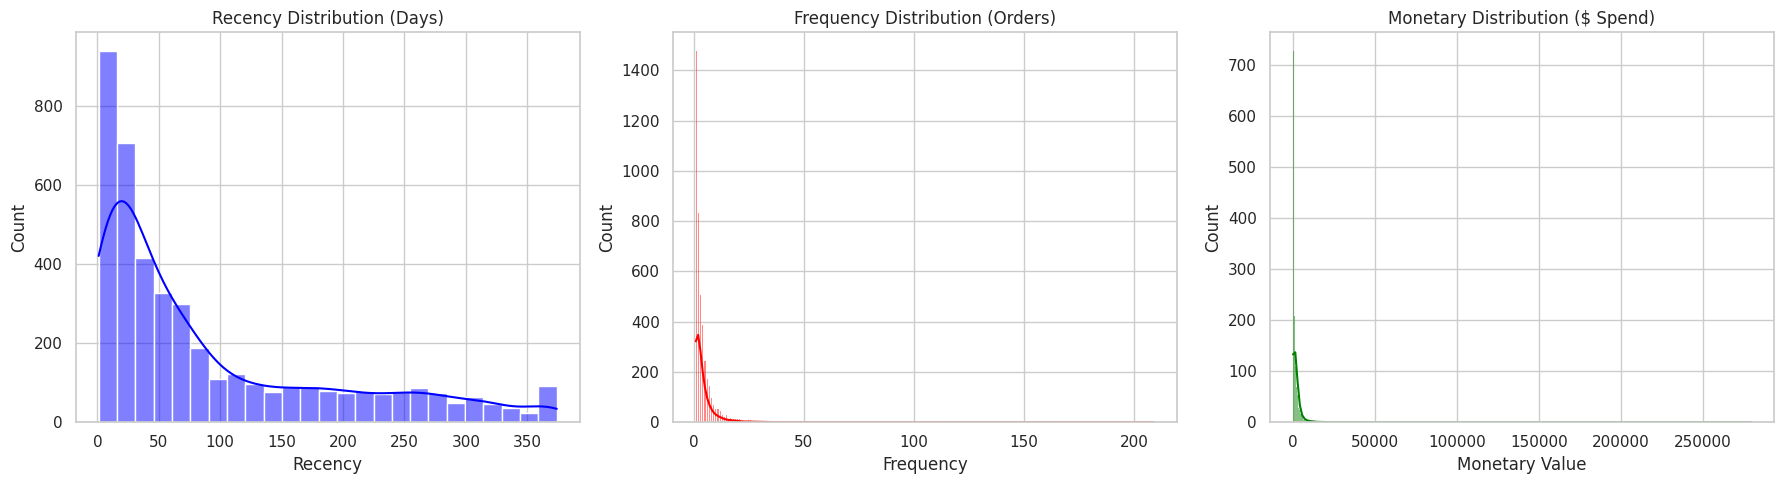

In [35]:
# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# 1. Recency Distribution
sns.histplot(rfm_clean['Recency'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Recency Distribution (Days)')
axes[0].set_xlabel('Recency')
# 2. Frequency Distribution
sns.histplot(rfm_clean['Frequency'], kde=True, ax=axes[1], color='red')
axes[1].set_title('Frequency Distribution (Orders)')
axes[1].set_xlabel('Frequency')
# 3. Monetary Distribution
sns.histplot(rfm_clean['Monetary'], kde=True, ax=axes[2], color='green')
axes[2].set_title('Monetary Distribution ($ Spend)')
axes[2].set_xlabel('Monetary Value')
plt.tight_layout()
plt.show()

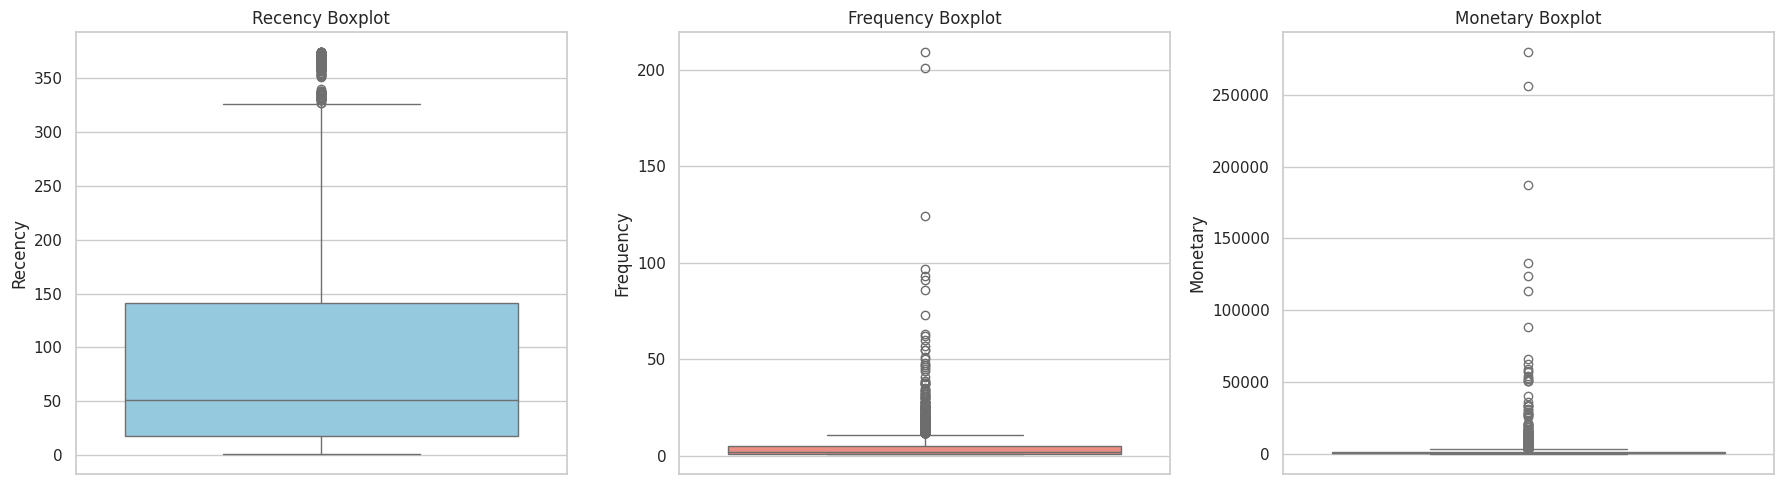

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot for Recency
sns.boxplot(y=rfm_clean['Recency'], ax=axes[0], color='skyblue')
axes[0].set_title('Recency Boxplot')

# Boxplot for Frequency
sns.boxplot(y=rfm_clean['Frequency'], ax=axes[1], color='salmon')
axes[1].set_title('Frequency Boxplot')

# Boxplot for Monetary
sns.boxplot(y=rfm_clean['Monetary'], ax=axes[2], color='lightgreen')
axes[2].set_title('Monetary Boxplot')

plt.tight_layout()
plt.show()

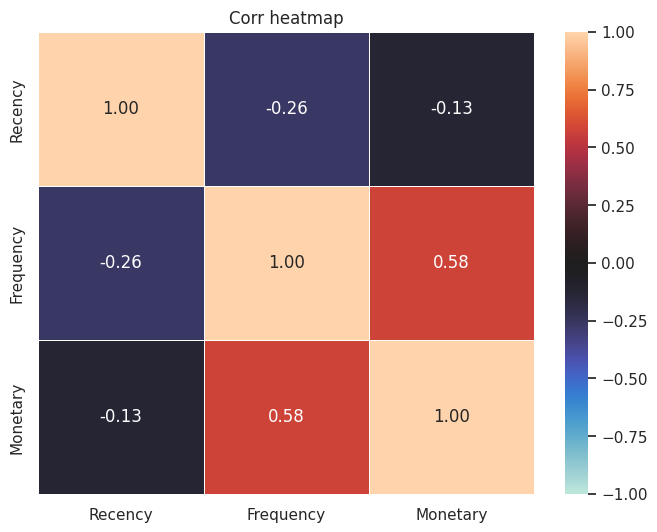

In [37]:
'''
a huge skew to right data .
the data shows that i have huge purshases made by outliers in comparason to the 
main avg customer 
so lets see correlation heatmap too for the data 

'''
corr_matrix = rfm_clean[['Recency' ,'Frequency' , 'Monetary' ]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
    annot=True ,
    cmap='icefire',
    fmt='.2f',
    vmax=1,
    vmin=-1,
    linewidth = 0.5
)
plt.title('Corr heatmap')
plt.show()

### after data analysis and RFM prep and visualization lets step into the K-mean clustering 

In [38]:
#fix the skewness 
#import sklearn
from sklearn.preprocessing import StandardScaler

#  Log transform to remove right-skewness
rfm_log = np.log1p(rfm_clean[['Recency', 'Frequency', 'Monetary']])

# then Standardize features to mean=0, std=1
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [39]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
K_range = range(2, 12) # choosed 7 hear due to gut feeling based on the data shape

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))


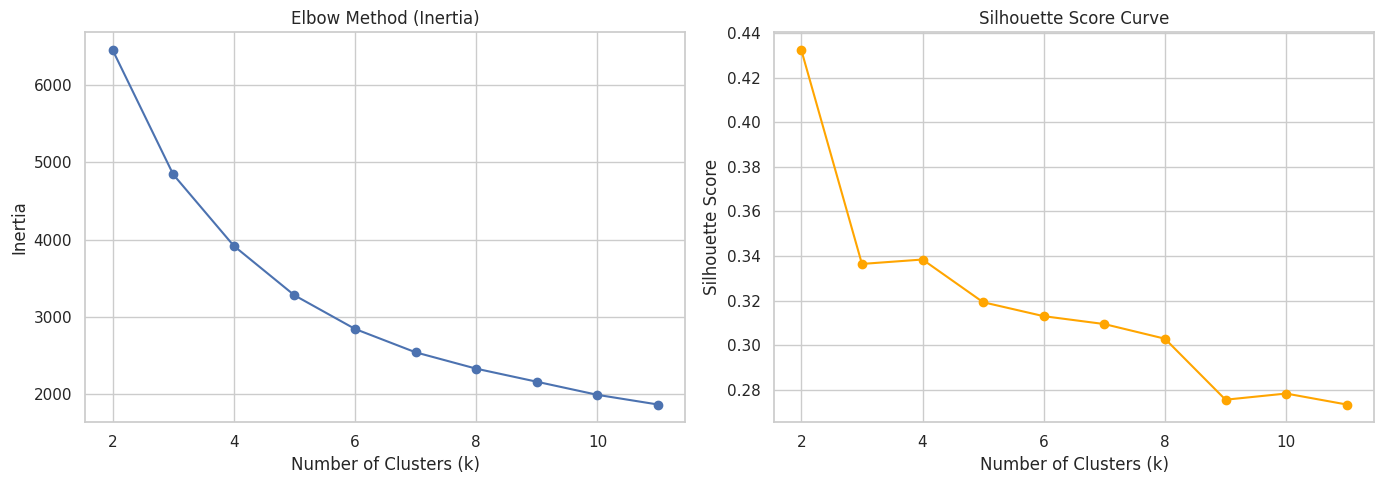

In [40]:
# Plot Elbow and Silhouette curves
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(K_range, inertia, marker='o', color='b')
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia')

ax[1].plot(K_range, silhouette_scores, marker='o', color='orange')
ax[1].set_title('Silhouette Score Curve')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [41]:
# Train final K-Means model with k=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_clean['Cluster'] = kmeans.fit_predict(rfm_scaled)

# View average metrics per cluster
cluster_profile = rfm_clean.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

cluster_profile

Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         17.27      2.20   555.69   821
1         70.47      4.05  1615.29  1189
2         12.24     13.82  7645.42   707
3        182.19      1.32   331.57  1602

# The Customer segementaion 

In [42]:
# 1. Map cluster numbers to persona names based on your summary table
cluster_map = {
    2: 'Champions (VIP)',
    1: 'Loyal Customers',
    0: 'New / Promising',
    3: 'Lost / Churned'
}
rfm_clean['Customer_Segment'] = rfm_clean['Cluster'].map(cluster_map)

/tmp/ipykernel_16/413530527.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')


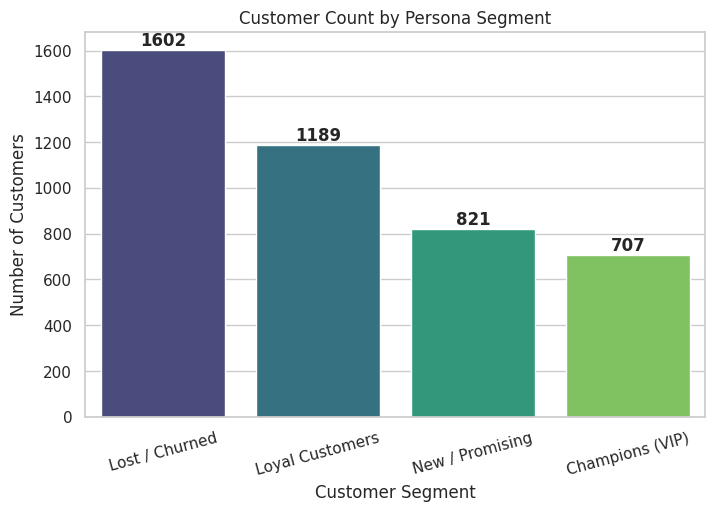

In [43]:
plt.figure(figsize=(8, 5))
segment_counts = rfm_clean['Customer_Segment'].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')
plt.title('Customer Count by Persona Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
for i, v in enumerate(segment_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.show()

/tmp/ipykernel_16/3881293331.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x='Customer_Segment', y='Recency', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_16/3881293331.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x='Customer_Segment', y='Frequency', ax=axes[1], palette='Reds')
/tmp/ipykernel_16/3881293331.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x='Customer_Segment', y='Monetary', ax=axes[2], palette='Greens')


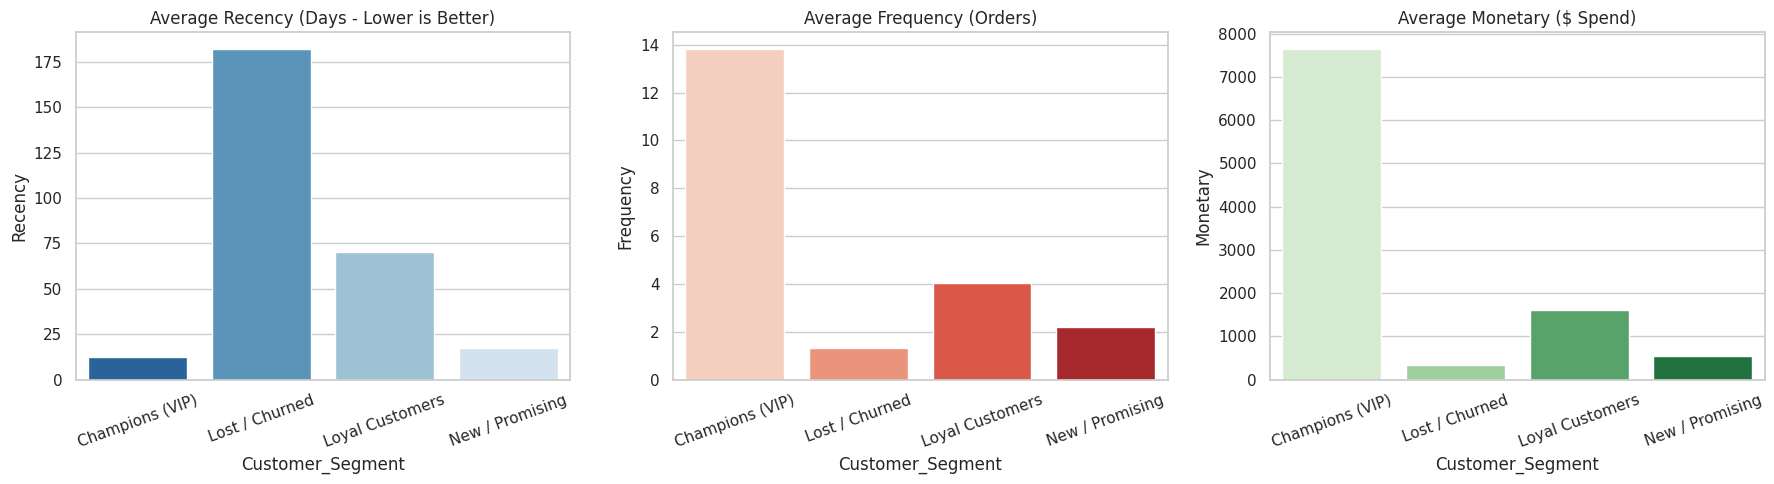

In [44]:
segment_summary = rfm_clean.groupby('Customer_Segment')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Recency (Lower is better)
sns.barplot(data=segment_summary, x='Customer_Segment', y='Recency', ax=axes[0], palette='Blues_r')
axes[0].set_title('Average Recency (Days - Lower is Better)')
axes[0].tick_params(axis='x', rotation=20)
# Frequency (Higher is better)
sns.barplot(data=segment_summary, x='Customer_Segment', y='Frequency', ax=axes[1], palette='Reds')
axes[1].set_title('Average Frequency (Orders)')
axes[1].tick_params(axis='x', rotation=20)
# Monetary (Higher is better)
sns.barplot(data=segment_summary, x='Customer_Segment', y='Monetary', ax=axes[2], palette='Greens')
axes[2].set_title('Average Monetary ($ Spend)')
axes[2].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

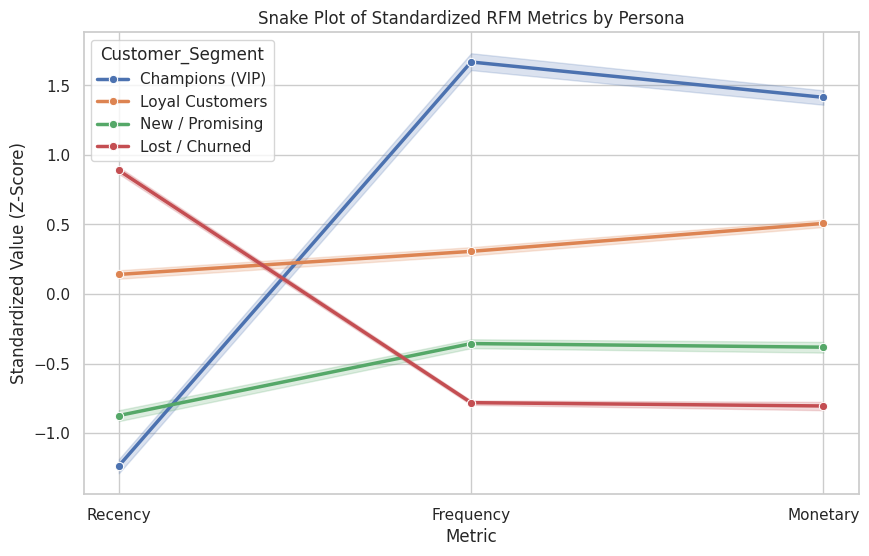

In [45]:

'''
trying snakeplot for RFM
A Snake Plot (parallel coordinates plot) displays standardized z
z-scores across Recency, Frequency, and Monetary on a line chart.
It visually shows where each segment excels or drops (e.g., Champions spike high on Frequency and Monetary, while Lost customers dip low).
'''
# Create DataFrame with scaled features and persona labels
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df['Customer_Segment'] = rfm_clean['Customer_Segment'].values
# Melt DataFrame into long format for Snake Plot
rfm_melted = pd.melt(rfm_scaled_df, id_vars=['Customer_Segment'], 
                     var_name='Metric', value_name='Standardized_Value')
plt.figure(figsize=(10, 6))
sns.lineplot(data=rfm_melted, x='Metric', y='Standardized_Value', hue='Customer_Segment', marker='o', linewidth=2.5)
plt.title('Snake Plot of Standardized RFM Metrics by Persona')
plt.ylabel('Standardized Value (Z-Score)')
plt.grid(True)
plt.show()

# Monthly Cohort Retention Heatmap
    to work on the Retention of customers 

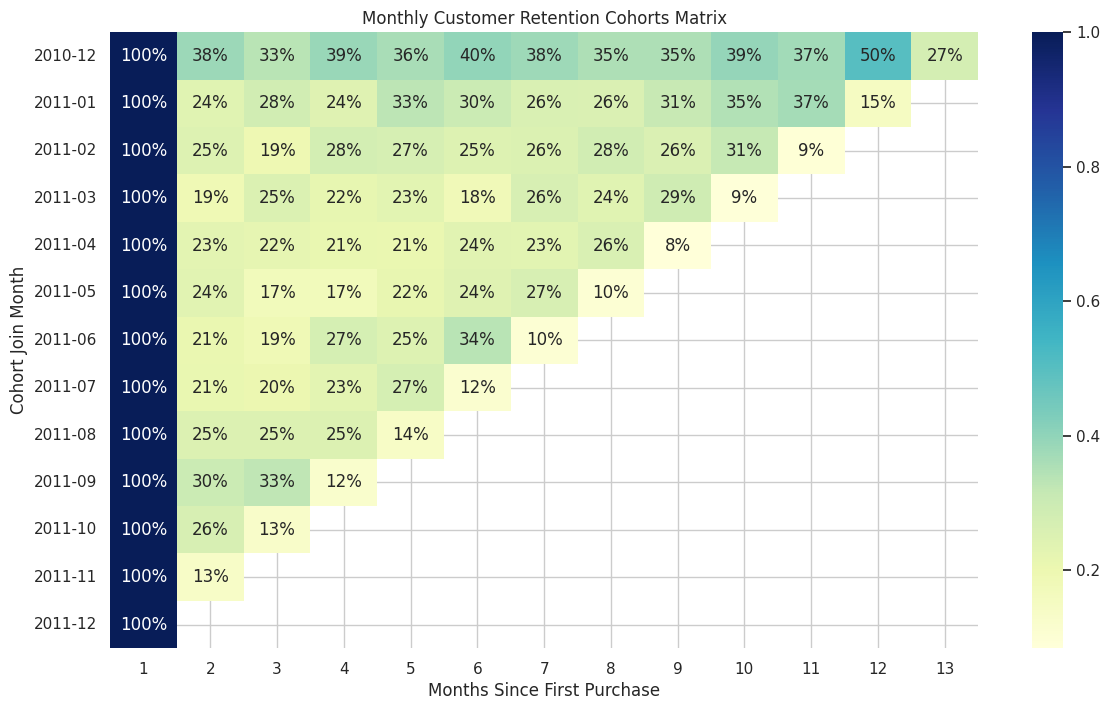

In [46]:
# 1. Extract invoice month and cohort month (first purchase month per customer)
data['InvoiceMonth'] = data['InvoiceDate'].dt.to_period('M')
data['CohortMonth'] = data.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

# 2. Calculate months elapsed since first purchase (CohortIndex)
data['CohortIndex'] = (data['InvoiceMonth'].dt.year - data['CohortMonth'].dt.year) * 12 + \
                      (data['InvoiceMonth'].dt.month - data['CohortMonth'].dt.month) + 1

# 3. Count unique active customers per cohort month & cohort index
cohort_counts = data.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

# 4. Pivot into a cohort matrix
cohort_matrix = cohort_counts.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# 5. Calculate percentage retention matrix
cohort_size = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_size, axis=0)

# 6. Plot Retention Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Monthly Customer Retention Cohorts Matrix')
plt.ylabel('Cohort Join Month')
plt.xlabel('Months Since First Purchase')
plt.show()

the last conclusion
Month 1: The month they joined (e.g., Dec 2010).
Month 2: 1 month later (Jan 2011).
Month 3: 2 months later (Feb 2011), etc.
cohort (Month 1 count) to calculate the Retention Rate (%)

----
The Month 2 Drop-off (75% Immediate Churn):

Across almost all cohorts (from Jan 2011 to Nov 2011), retention drops from 100% down to 19% – 25% in Month 2.
Business Meaning: Around 75% to 80% of new customers are one-time buyers who do not return for a second purchase in the following month.
The December 2010 Cohort is Exceptional:

The very first row (2010-12) is by far your strongest cohort:
Retains 38% in Month 2.
Stays consistently high (35% to 40%) for the entire year.
Spikes to 50% in Month 12 (likely due to holiday shopping in Dec 2011!)